# Load ERA5-Land Data

In [1]:
# auto reload modified modules
%load_ext autoreload
%autoreload 2
import sys
WORK_DIR = "/home/research/jenzheng/documents/kai/research/eta/eta"
sys.path.append(WORK_DIR)

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from plot_utils import plot_setting, plot_nfields 
from utils import *
import torch
import torch.nn as nn
from kde import get_data_pdf
plot_setting()

# Load the cropped data
file_path = WORK_DIR + '/data/ERA5/era5land_USA_SouthEast_1999-2023_dailymax.nc'
ds = xr.open_dataset(file_path, engine='netcdf4')

# Extract the 'tp' variable (Total Precipitation)
tp = ds['tp']

# Convert to a NumPy array and multiply by 1000 (meter to millimeter)
tp_numpy = tp.values * 1000
# 
# Check if there are any NaN values
has_nan = np.isnan(tp_numpy).any()
# print(f"Contains NaN values: {has_nan}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

<xarray.DataArray 'tp' (time: 9050, latitude: 80, longitude: 160)> Size: 463MB
[115840000 values with dtype=float32]
Coordinates:
  * time        (time) datetime64[ns] 72kB 1999-01-01T11:30:00 ... 2023-12-31...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
  * latitude    (latitude) float64 640B 38.7 38.6 38.5 38.4 ... 31.0 30.9 30.8
  * longitude   (longitude) float64 1kB -97.6 -97.5 -97.4 ... -81.9 -81.8 -81.7
    valid_time  (time) datetime64[ns] 72kB ...
Attributes: (12/29)
    GRIB_paramId:                             228
    GRIB_numberOfPoints:                      150851
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    ...                                       ...
    GRIB_name:                                Total precipitation
    GRIB_shortName:                           tp
    GRIB_uni

# Downsample Data

In [2]:
# Downsampling by a factor of ds_fact for each spatial dimension
ds_fact = 10
tp_ds_numpy = tp_numpy[:, ::ds_fact, ::ds_fact]  # (9050, 40, 80)

# Data Preprocessing

In [ ]:
max_values_original = np.max(tp_numpy, axis=(1, 2))

# max_values_original will have shape (9050,)
print(max_values_original.shape)

# Sort max_values and get the indices that would sort the array
sorted_indices_original = np.argsort(max_values_original)
print(0 in sorted_indices_original)

# Use the sorted_indices to get the sorted max_values
sorted_max_values_original = max_values_original[sorted_indices_original]

# trim the tail
trim_tail_thresh = 240
num_trim_days = len(sorted_max_values_original[sorted_max_values_original > trim_tail_thresh])
trim_days = sorted_indices_original[-num_trim_days:]
sorted_max_values_trim = sorted_max_values_original[:-num_trim_days]
sorted_indices_trim = sorted_indices_original[:-num_trim_days]
print("Trimmed Days: ", trim_days)
print("Trimmed Values: ", sorted_max_values_original[-num_trim_days:])

kept_days = np.delete(np.arange(len(tp_numpy)), trim_days)
tp_trim_numpy = tp_numpy[kept_days]
tp_trim_ds_numpy = tp_ds_numpy[kept_days]
tp_trim_tensor = torch.tensor(tp_trim_numpy)
tp_trim_ds_tensor = torch.tensor(tp_trim_ds_numpy)
print(tp_trim_ds_tensor.shape)
print(tp_trim_tensor.shape)

# Select Training Data

In [10]:
import torch.optim as optim
from rich.progress import Progress
from torch.utils.data import DataLoader, TensorDataset
from copy import deepcopy
import os
import gc

# Convert numpy arrays to PyTorch tensors and move to GPU
tp_trim_ds_tensor = torch.tensor(tp_trim_ds_numpy, dtype=torch.float32).unsqueeze(1).to(device)  # Add channel dimension
tp_trim_tensor = torch.tensor(tp_trim_numpy, dtype=torch.float32).unsqueeze(1).to(device)  # Full-resolution target

# Use 20% of the data (5 years) for training
num_years = 0.5
portion = num_years/25
train_size = int(portion * len(tp_trim_ds_tensor))
train_input = tp_trim_ds_tensor[:train_size]
train_target = tp_trim_tensor[:train_size]

# use full data to select the best MSE model for baseline comparison
test_input = deepcopy(tp_trim_ds_tensor)
test_target = deepcopy(tp_trim_tensor)

# move data to device
train_input = train_input.to(device)
train_target = train_target.to(device)
test_input = test_input.to(device)
test_target = test_target.to(device)

# Create DataLoader for batch processing
batch_size = 64
train_dataset = TensorDataset(train_input, train_target)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataset = TensorDataset(test_input, test_target)
test_loader = DataLoader(test_dataset, batch_size=25*batch_size, shuffle=False)

print(train_input.shape)
print(train_target.shape)
print(test_input.shape)
print(test_target.shape)

torch.Size([180, 1, 8, 16])
torch.Size([180, 1, 80, 160])
torch.Size([9044, 1, 8, 16])
torch.Size([9044, 1, 80, 160])


# Training Data v.s. Full Data PDF

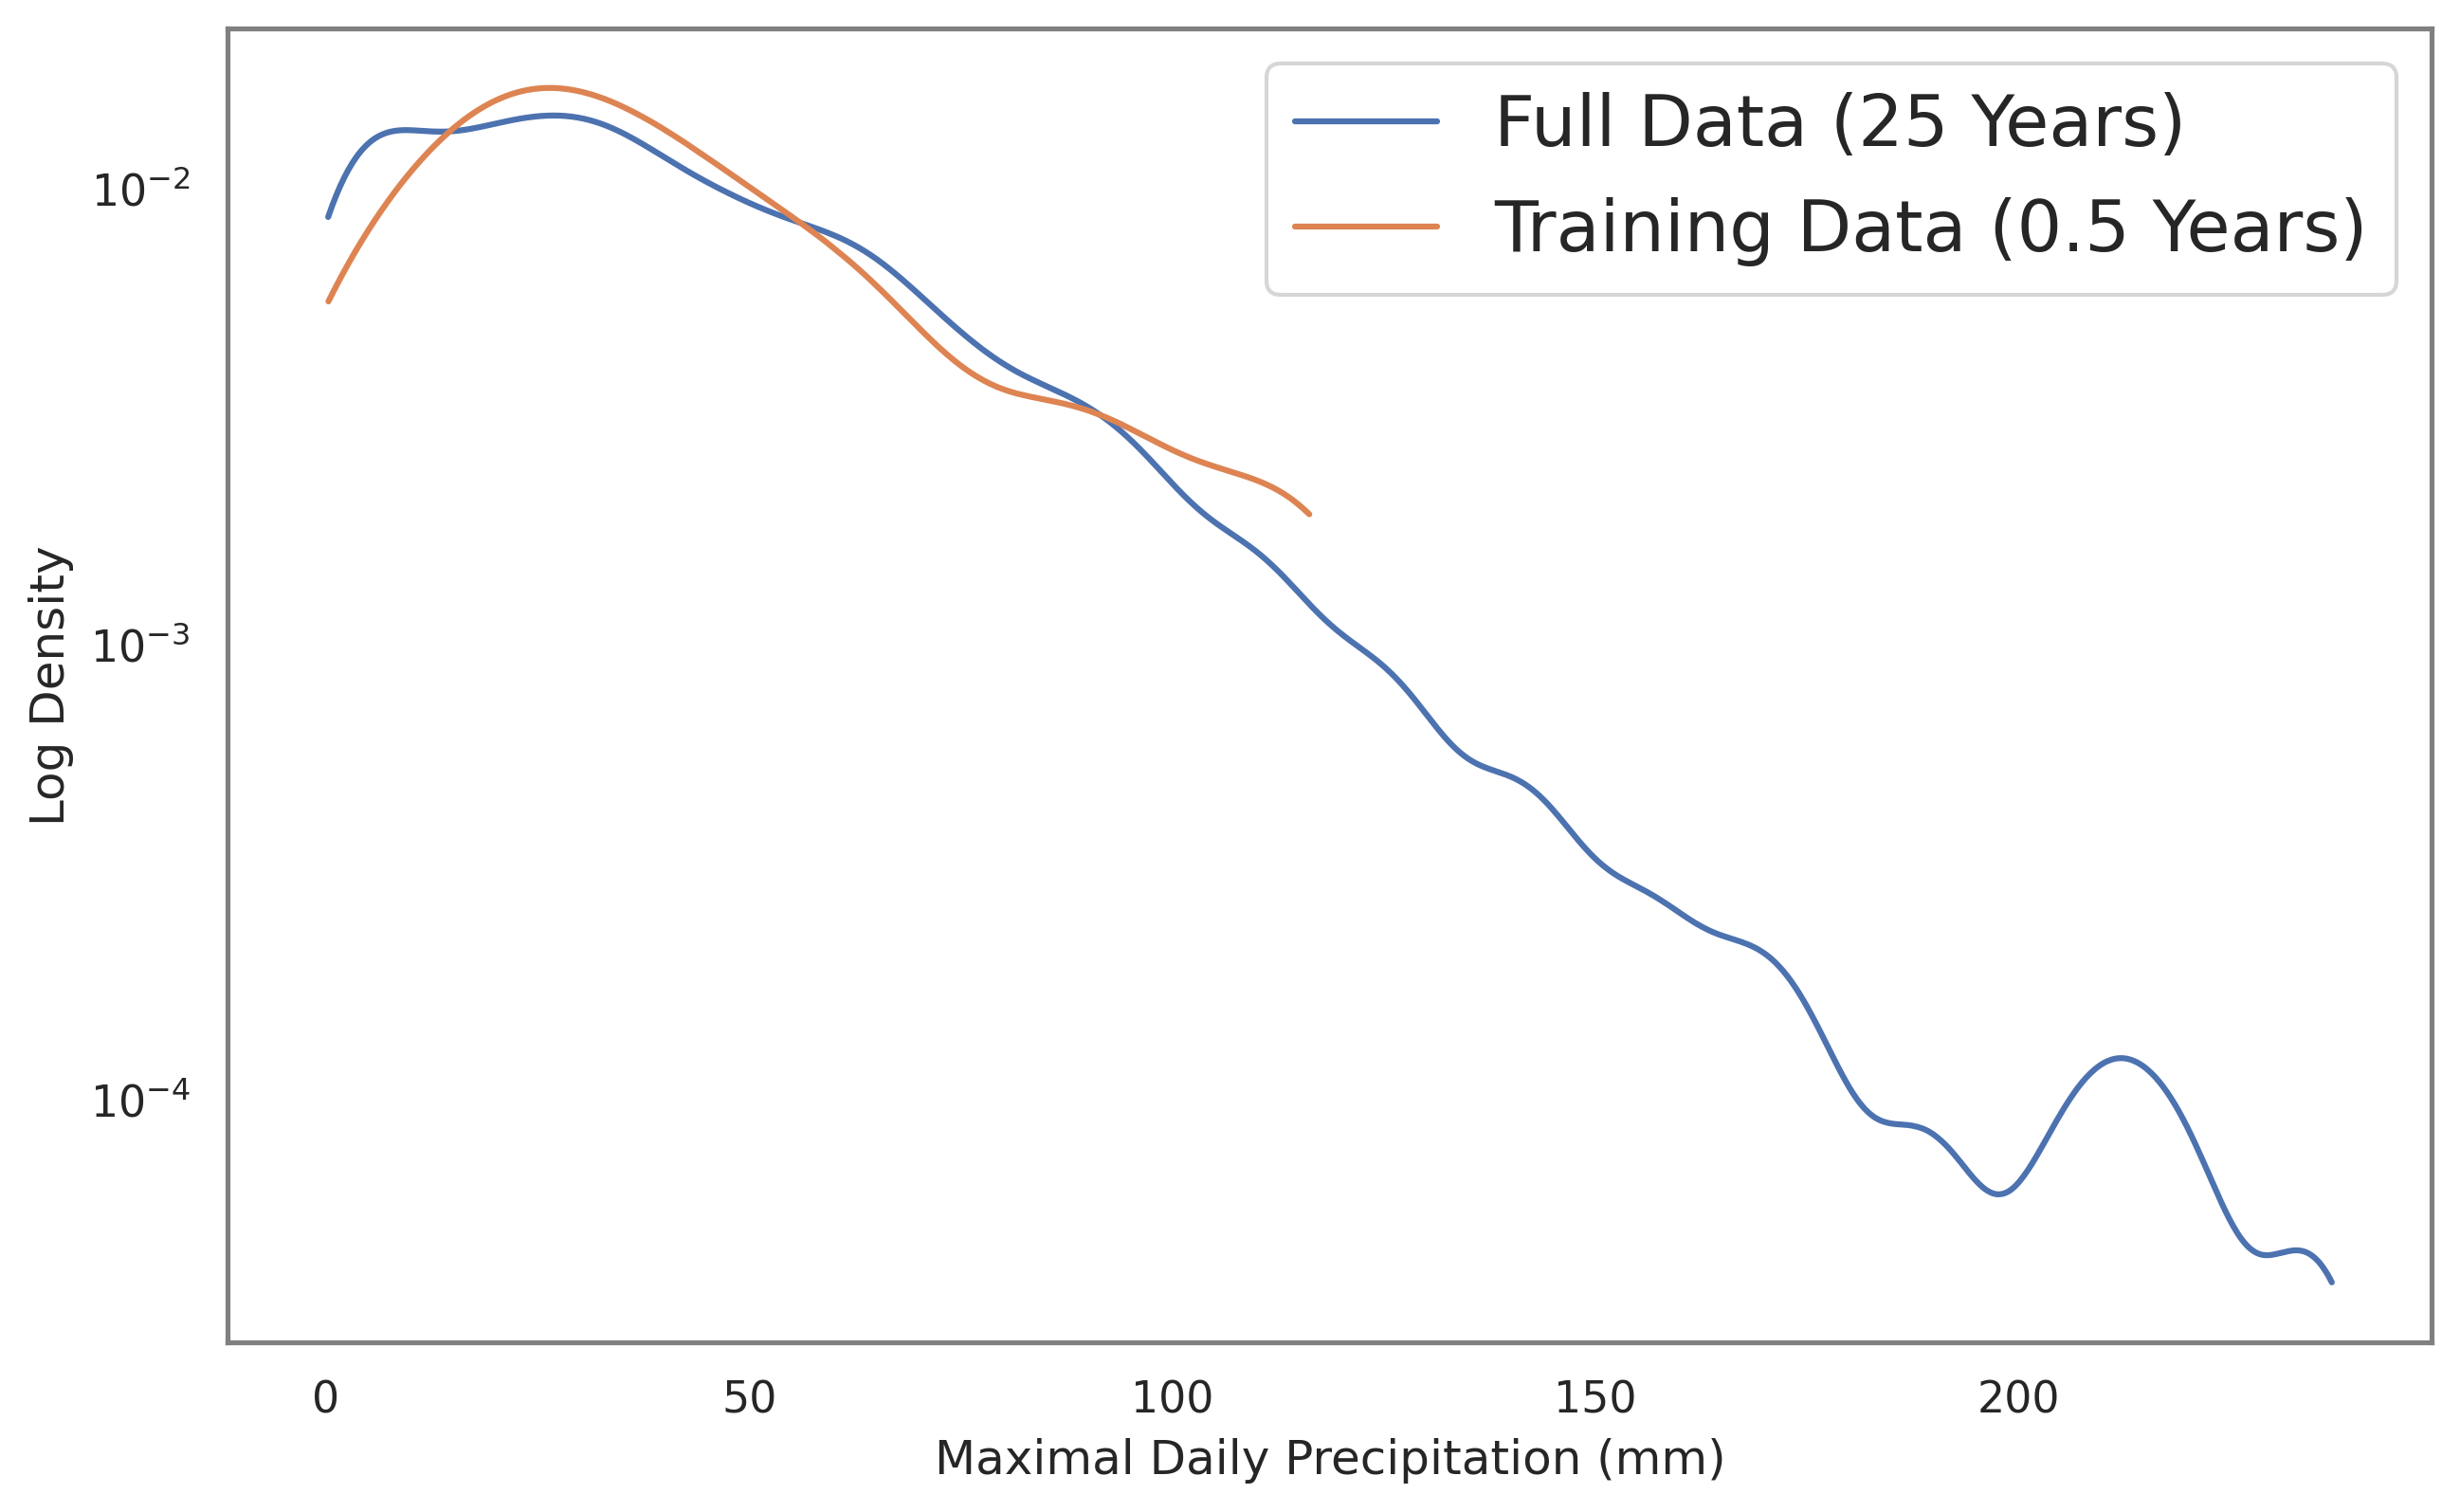

In [11]:
train_max_values = np.max(tp_trim_numpy[:train_size], axis=(1, 2))
y_eval_tp_train, py_tp_train, _ = get_data_pdf(data=torch.tensor(train_max_values), data_all=torch.tensor(train_max_values))

# Plotting the two KDEs for comparison
plt.figure(figsize=(10, 6), dpi=300)

# Plot the KDE for the original data
plt.plot(y_eval_tp, py_tp, label="Full Data (25 Years)")
plt.plot(y_eval_tp_train, py_tp_train, label=f"Training Data ({num_years} Years)")

# Add plot labels and title
plt.xlabel("Maximal Daily Precipitation (mm)")
plt.ylabel("Log Density")
# plt.title("PDF of Regional Max Precipitation", fontsize=14)
plt.yscale('log')
plt.legend(prop={"size" : 18})

# Start Training MSE

In [12]:
"""
Training with MSE Loss. No need if pretrained model is available.
"""
from models import SRCNN
seed = 43
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Initialize CNN model, optimizer, and loss function
# model_mse = SRCNN(in_channels=1, out_channels=1)
model_mse = SRCNN(hidden_dim=64, num_blocks=3, scale_factor=ds_fact)

# Move model and data to multiple GPUs
model_mse = nn.DataParallel(model_mse)  # Use all available GPUs
model_mse.to(device)

# optimizer and loss
optimizer = optim.Adam(model_mse.parameters(), lr=3e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=.2)
mse_loss = nn.MSELoss()

# Training settings
num_epochs = 500
grad_clip = 1

# Checkpoint
save_mse = False
best_loss = float('inf')
save_dir = WORK_DIR + "/models/precip-srcnn/"
os.makedirs(save_dir, exist_ok=True)
model_mse_filename = f"srcnn-mse-{num_years}yr-{ds_fact}ds.pth"
save_path_mse = os.path.join(save_dir, model_mse_filename)
print(save_path_mse)

with Progress() as progress:
    print("Training Started")
    epoch_task = progress.add_task("Training Epochs", total=num_epochs)

    for epoch in range(num_epochs):
        running_train_loss = 0.0
        running_test_loss = 0.0
        # Progress bar for each epoch
        # batch_task = progress.add_task(f"Epoch {epoch+1}/{num_epochs}", total=len(train_loader))
        
        model_mse.train()
        for batch_idx, (input_data, target) in enumerate(train_loader):
            model_mse.train()
            
            # Zero the gradients
            optimizer.zero_grad()
            
            # Forward pass
            output = model_mse(input_data)

            # Compute loss
            loss = mse_loss(output, target)
            
            # Backward pass
            loss.backward()
            
            # Gradient clipping
            # torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            
            # Update weights
            optimizer.step()
    
            # Update progress bar for each batch
            # progress.update(batch_task, advance=1)
            
            # Update loss
            running_train_loss += loss.item()
        
        epoch_train_loss = running_train_loss/len(train_loader)
        scheduler.step()
        
        model_mse.eval()
        with torch.no_grad():
            for _, (test_in, test_tar) in enumerate(test_loader):
                test_output = model_mse(test_in)
                loss = mse_loss(test_output, test_tar)
                running_test_loss += loss.item()
                
            epoch_test_loss = running_test_loss/len(test_loader)
            if epoch_test_loss < best_loss:
                best_loss = epoch_test_loss
                if save_mse:
                    torch.save(model_mse.state_dict(), save_path_mse)
            
        # Update epoch progress bar
        progress.update(epoch_task, advance=1)
        progress.console.print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {epoch_train_loss:.6f}, Best Val Loss: {best_loss:.6f}")#, Average Upsample Loss : {upsample_loss/len(train_loader):.6f}")


# Load Trained MSE Model (If Applicable)

In [13]:
# load path
load_dir = WORK_DIR + "/models/precip-srcnn/"
os.makedirs(load_dir, exist_ok=True)

# model name
model_mse_filename = f"srcnn-mse-{num_years}yr-{ds_fact}ds.pth"
print(model_mse_filename)
# save model
load_path = os.path.join(load_dir, model_mse_filename)

# load model
model_mse = SRCNN(hidden_dim=64, num_blocks=3, scale_factor=ds_fact)
model_mse = nn.DataParallel(model_mse)
model_mse.load_state_dict(torch.load(load_path))
model_mse.to(device)
print()

srcnn-mse-0.5yr-10ds.pth



# Run MSE-Model on Trimmed Dataset

In [15]:
from test_utils import test_model_mse
test_dataset = TensorDataset(test_input, test_target)
test_loader = DataLoader(test_dataset, batch_size=20*batch_size, shuffle=False)

full_output_mse, test_mse_loss_mse = test_model_mse(model_mse, test_loader)
print(full_output_mse.shape)
print("MSE Test Loss:", test_mse_loss_mse)

(9044, 80, 160)
MSE Test Loss: 7.888037443161011


# MSE Output PDF

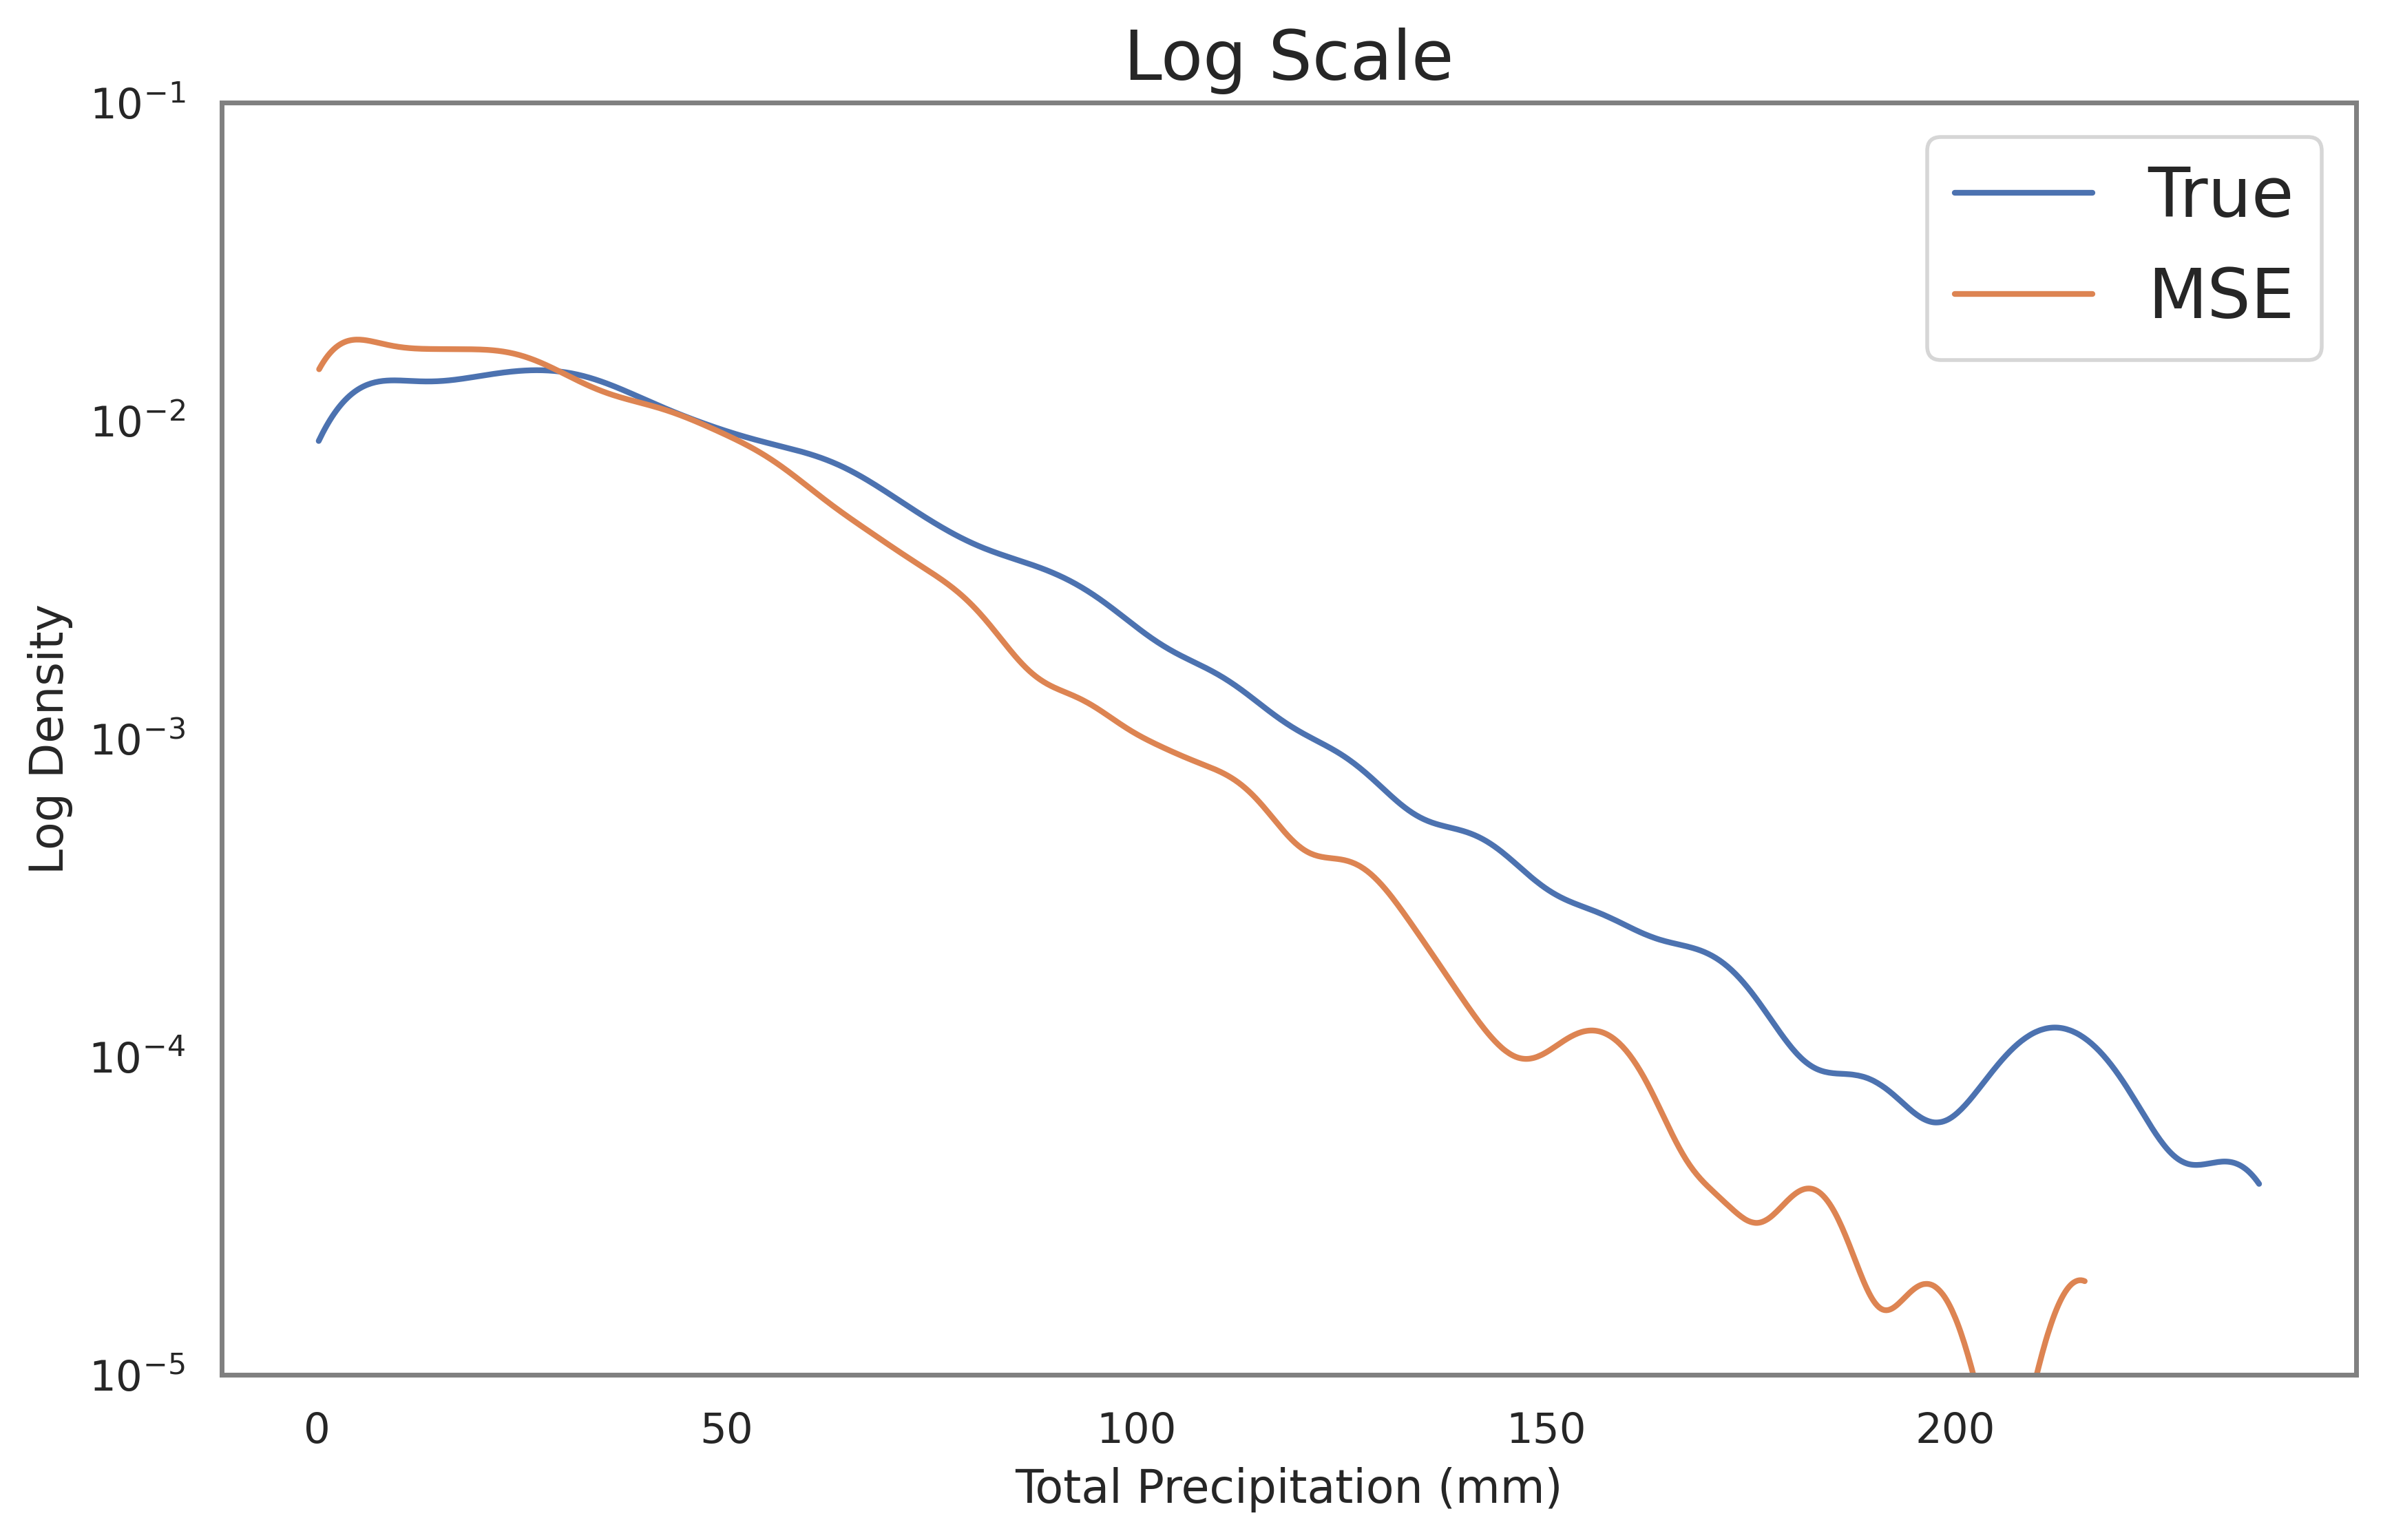

In [16]:
max_values_mse = np.max(full_output_mse, axis=(1,2))
y_eval_tp_mse, py_tp_mse, _ = get_data_pdf(data=torch.tensor(max_values_mse), data_all=torch.tensor(max_values_mse))

# Plotting the two KDEs for comparison
plt.figure(figsize=(10, 6), dpi=400)

# Plot the KDE for the original data
plt.plot(y_eval_tp, py_tp, label="True")
# plt.plot(y_eval_tp_train, py_tp_train, label="5 Years True")
plt.plot(y_eval_tp_mse, py_tp_mse, label="MSE")

# Add plot labels and title
plt.xlabel("Total Precipitation (mm)")
plt.ylabel("Log Density")
plt.title("Log Scale", fontsize=18)
plt.ylim(1e-5,1e-1)
plt.yscale('log')
plt.legend(prop={'size':18})

# ETA with W1 Loss

In [17]:
# tail threshold, equivalent to \tau in the paper
w1_tail_thresh = 150

# sort max values
max_values = np.max(tp_trim_numpy, axis=(1,2))
sorted_indices = np.argsort(max_values)
sorted_max_values = max_values[sorted_indices]

# get tail that defines w1
num_w1_days = len(sorted_max_values[sorted_max_values > w1_tail_thresh])
w1_truedays = sorted_indices[-num_w1_days:]
w1_input = tp_trim_ds_numpy[w1_truedays]
w1_input = torch.tensor(w1_input).unsqueeze(1)
w1_truemax = torch.tensor(sorted_max_values[-num_w1_days:])
print("w1_input shape:", w1_input.shape)
print(w1_truemax)

def get_fixed_days_max_pos(full_output: np.ndarray, w1_days):
    """
    helper function - get the location index of the tail values 
    
    input:
        - selected days: 
        
    """
    max_indices = np.argmax(full_output.reshape(full_output.shape[0], -1), axis=1)
    max_pos_row, max_pos_col = np.unravel_index(max_indices, (80,160))
    max_pos = np.stack([np.arange(full_output.shape[0]), max_pos_row, max_pos_col], axis=1).T
    
    num_w1_days = len(w1_days)
    fixed_days_max_pos = torch.tensor(max_pos[:,w1_days])
    fixed_days_max_pos = torch.cat((torch.arange(num_w1_days).reshape(1,-1), fixed_days_max_pos[1:,:]), dim=0)
    fixed_days_max_pos.requires_grad = False
    
    return fixed_days_max_pos

def get_max_time_pos(full_output : np.ndarray, num_w1_days):
    """
    helper function - get the time and location index of the tail values 
    
    input:
        - full_output: output of model running on the entire testing dataset
        - num_w1_days: number of tail days taken, equivalent to n_q (number of 
                       pre-determined quantile levels) in the paper
    """
    # get w1_days
    max_values_output = np.max(full_output, axis=(1,2))
    sorted_indices_output = np.argsort(max_values_output)
    w1_days = sorted_indices_output[-num_w1_days:]
    
    # get w1_max_pos
    max_indices = np.argmax(full_output.reshape(full_output.shape[0], -1), axis=1)
    max_pos_row, max_pos_col = np.unravel_index(max_indices, (80,160))
    max_pos = np.stack([np.arange(full_output.shape[0]), max_pos_row, max_pos_col], axis=1).T
    w1_max_pos = torch.tensor(max_pos[:,w1_days])
    w1_max_pos = torch.cat((torch.arange(num_w1_days).reshape(1,-1), w1_max_pos[1:,:]), dim=0)
    w1_max_pos.requires_grad = False
    
    return w1_days, w1_max_pos
    

# def get_w1_objects_dynamic_days():
#     pass

w1_truedays_max_pos = get_fixed_days_max_pos(full_output_mse, w1_truedays)
w1_days, w1_max_pos = get_max_time_pos(full_output_mse, num_w1_days)
overlap = np.intersect1d(np.asarray(sorted(w1_truedays)), np.asarray(sorted(w1_days)))
print(len(overlap))
print(num_w1_days)

w1_input shape: torch.Size([102, 1, 8, 16])
tensor([151.0163, 151.7466, 151.7830, 153.3869, 153.4816, 153.9133, 154.0040,
        154.0336, 154.5159, 154.7079, 155.4734, 155.4734, 155.5128, 155.6336,
        155.9998, 156.2277, 156.7999, 156.8206, 156.8268, 156.8434, 156.9400,
        157.4302, 158.8081, 159.7999, 159.8695, 159.8775, 160.7206, 160.8302,
        161.3650, 161.3658, 162.5149, 163.0251, 165.0917, 165.0917, 165.3987,
        165.3995, 167.6138, 167.6982, 167.7163, 168.4133, 168.4133, 168.5618,
        168.5783, 169.6184, 169.7310, 169.7310, 170.2376, 170.2681, 170.4438,
        170.6319, 173.5678, 173.5686, 173.7072, 174.2222, 174.6448, 174.6651,
        174.6858, 178.3278, 178.3278, 178.9393, 179.0438, 183.7197, 186.0995,
        188.0396, 188.3646, 188.5554, 188.5588, 188.7238, 190.0555, 190.7344,
        193.9114, 195.4431, 201.1539, 201.1539, 203.1031, 204.6013, 205.8019,
        208.1167, 208.4353, 208.4655, 210.0206, 210.8896, 211.1220, 211.1416,
        211.1515, 21

In [18]:
def get_w1_input(w1_days):
    """
    function to get w1 loss input
    """
    w1_input = tp_trim_ds_numpy[w1_days]
    w1_input = torch.tensor(w1_input).unsqueeze(1)
    return w1_input
    
num_mse_years = num_years
mse_portion = num_mse_years/25
mse_size = int(mse_portion * len(tp_trim_ds_tensor))
mse_input = tp_trim_ds_tensor[:mse_size]
mse_target = tp_trim_tensor[:mse_size]

print(mse_input.shape)
print(mse_target.shape)

# move data to device
w1_truemax = w1_truemax.to(device)
mse_input = mse_input.to(device)
mse_target = mse_target.to(device)

torch.Size([180, 1, 8, 16])
torch.Size([180, 1, 80, 160])


# ETA Testing Function

In [19]:
def test_model_eta(model, TestLoader, 
                   w1_loss, w1_truemax,
                   device=None):
    """
    run model on TestLoader and report the MSE loss and the W1 loss
    
    return:
        - full_output: squeezed numpy array with dimension (N,...)
        - test_loss_mse: mean squared error on TestLoader
    
    """
    if not device:
        device = next(model.parameters()).device
    model.to(device)
    model.eval()
    _, sample_target = next(iter(TestLoader))
    full_output = torch.zeros_like(sample_target[0]).cpu()
    mse_loss = nn.MSELoss()
    running_test_mse_loss = 0.0
    
    with torch.no_grad():
        for _, (test_in, test_tar) in enumerate(test_loader):
            test_in, test_tar = test_in.to(device), test_tar.to(device)  
            test_output = model(test_in).detach()
            loss = mse_loss(test_output, test_tar)
            running_test_mse_loss += loss.item()
            full_output = torch.cat((full_output,test_output.squeeze().cpu()),dim=0)
    test_mse_loss = running_test_mse_loss/len(test_loader)
    
    # when testing, should record the true tail values
    num_w1_days = len(w1_truemax)
    full_output = full_output[1:].numpy()
    max_values_output = np.max(full_output, axis=(1,2))
    sorted_indices_output = np.argsort(max_values_output)
    sorted_max_values_output = max_values_output[sorted_indices_output]
    w1_max_test = torch.tensor(sorted_max_values_output[-num_w1_days:])
    w1_max_test = w1_max_test.to(w1_truemax.device)
    
#     w1_output_test = model(w1_input).squeeze()
#     w1_max_test = w1_output_test[tuple(w1_max_pos)]
    w1_loss_test = w1_loss(w1_max_test, w1_truemax).item()
    
    return full_output, test_mse_loss, w1_loss_test

def get_max_indices_vals(full_output : np.ndarray, num_w1_days):
    max_values_output = np.max(full_output, axis=(1,2))
    sorted_indices_output = np.argsort(max_values_output)
    sorted_max_values_output = max_values_output[sorted_indices_output]
    max_indices = sorted_indices_output[-num_w1_days:]
    max_vals = torch.tensor(sorted_max_values_output[-num_w1_days:])
    return max_indices, max_vals

# ETA Training Function

In [20]:
def train_model_eta(model_eta, test_loader, 
                    seed, num_epochs,
                    mse_input, mse_target,
                    w1_loss, w1_truemax, w1_truedays,
                    lambd_, omega:int, varying_days,
                    save_checkpoint=True, save_path=None,
                    scheduler=None, clip_gradient=False,
                    device=None):
    """
    Training function of \eta-learning
    
    Inputs:
        - model_eta: pretrained model with MSE
        - lambd_: loss balancing parameter
        - omega: window size 
    
    """
    
    global_seed(seed)
    if not device:
        device = next(model_eta.parameters()).device
    
    if save_checkpoint and not save_path:
        raise ValueError("No Path to Save Model!")
    
    # define mse_loss
    mse_loss = nn.MSELoss()
    
    # move data to device
    w1_truemax = w1_truemax.to(device)
    mse_input = mse_input.to(device)
    mse_target = mse_target.to(device)
    
    # for checkpoint use
    best_mse_loss = float('inf')
    best_w1_loss = float('inf')
    best_total_loss = float('inf')
    
    # record training loss history
    train_mse_loss_hist = []
    train_w1_loss_hist = []
    test_mse_loss_hist = []
    test_w1_loss_hist = []
    
    # get initialization of w1_days + w1_max_pos
    num_w1_days = len(w1_truedays)
    full_output_eta, _ = test_model_mse(model_eta, test_loader)
    w1_days = None
    if varying_days:
        w1_days, w1_max_pos = get_max_time_pos(full_output_eta, num_w1_days)
    else:
        w1_max_pos = get_fixed_days_max_pos(full_output_eta, w1_truedays)
        w1_days = w1_truedays
    w1_input = get_w1_input(w1_days)
    
    with Progress() as progress:
        epoch_task = progress.add_task("Training Epochs", total=num_epochs)

        for epoch in range(num_epochs):
            # could add minibatch training, but no need for this test case
            model_eta.train()

            # Zero the gradients
            optimizer.zero_grad()
            
            # get w1_input, move to device
            if varying_days:
                w1_input = get_w1_input(w1_days)
            w1_input = w1_input.to(device)
            
            # Forward pass
            mse_output = model_eta(mse_input)
            w1_output = model_eta(w1_input).squeeze()
            w1_max = w1_output[tuple(w1_max_pos)]

            # Compute loss
            mse_loss_val = mse_loss(mse_output, mse_target)
            w1_loss_val = w1_loss(w1_max, w1_truemax)
            
            # Backward pass
            loss = mse_loss_val + lambd_ * w1_loss_val
            loss.backward()

            # Gradient clipping
            if clip_gradient:
                torch.nn.utils.clip_grad_norm_(model_eta.parameters(), grad_clip)

            # Update weights
            optimizer.step()
            if scheduler:
                scheduler.step()
            
            # Run inference on more inputs
            full_output_eta, test_mse_loss_eta, w1_loss_test = test_model_eta(
                model_eta,
                test_loader,
                w1_loss,
                w1_input,
                w1_truemax,
                w1_max_pos,
                device=device
            )
            
            # update w1_max_pos whenever window size is reached
            if (epoch+1)%omega == 0:
                if varying_days:
                    w1_days, w1_max_pos = get_max_time_pos(full_output_eta, num_w1_days)
                else:
                    # here, w1_days = w1_truedays
                    w1_max_pos = get_fixed_days_max_pos(full_output_eta, w1_days)

            # save best w1 loss model
            if w1_loss_test < best_w1_loss:
                best_w1_loss = w1_loss_test
                best_mse_loss = test_mse_loss_eta
                if save_checkpoint:
                    torch.save(model_eta.state_dict(), save_path_eta)

            # save loss history
            train_mse_loss_hist.append(mse_loss_val)
            train_w1_loss_hist.append(w1_loss_val)
            test_mse_loss_hist.append(test_mse_loss_eta)
            test_w1_loss_hist.append(w1_loss_test)
            
            # Update epoch progress bar
            progress.update(epoch_task, advance=1)
            progress.console.print(
                f"Epoch {epoch+1}/{num_epochs}, "
#                 f"Best MSE Test Loss: {best_mse_loss:.6f}, "
#                 f"Best W1 Test Loss: {best_w1_loss:.6f}, "
#                 f"Curr W1 Test Loss: {w1_loss_test:.6f}"
                f"Best MSE: {best_mse_loss:.6f}, "
                f"Best W1: {best_w1_loss:.6f}, "
                f"Curr W1: {w1_loss_test:.6f}"
            )
#             progress.console.print(f"Epoch {epoch+1}/{num_epochs}, Best MSE Test Loss: {best_mse_loss:.6f}, Best W1 Test Loss: {best_w1_loss:.6f}")
    
    loss_dict = {
        "train_mse" : train_mse_loss_hist,
        "train_w1" : train_w1_loss_hist,
        "test_mse" : test_mse_loss_hist,
        "test_w1" : test_w1_loss_hist
    }
    
    return model_eta, loss_dict

In [21]:
# training components
seed = 43
global_seed(seed)
model_eta = deepcopy(model_mse).to(device)
num_epochs = 150
optimizer = optim.Adam(model_eta.parameters(), lr=3e-4)
w1_loss = lambda x,y: torch.abs(x-y).mean()
lambd_ = 1.
omega = 30 # window size
varying_days = True
test_dataset = TensorDataset(test_input, test_target)
test_loader = DataLoader(test_dataset, batch_size=50*batch_size, shuffle=False)

# training techniques
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=.6)
# clip_gradient = False

# checkpoint
save_eta = True
best_mse_loss = float('inf')
best_w1_loss = float('inf')
best_total_loss = float('inf')
save_dir = WORK_DIR + "/models/precip-srcnn/"
os.makedirs(save_dir, exist_ok=True)
model_eta_filename = f"srcnn-eta-{num_years}yr-{ds_fact}ds-{w1_tail_thresh}tail-{omega}omega.pth"
save_path_eta = os.path.join(save_dir, model_eta_filename)
print(save_path_eta)


/home/research/jenzheng/documents/kai/research/eta/models/precip-srcnn/srcnn-eta-0.5yr-10ds-150tail-30omega.pth


In [22]:
# model_eta, loss_dict_eta = train_model_eta(
#     model_eta, 
#     test_loader, 
#     seed,
#     num_epochs,
#     mse_input, 
#     mse_target,
#     w1_loss, 
#     w1_truemax, 
#     w1_truedays,
#     lambd_, 
#     omega, 
#     varying_days,
#     save_checkpoint=save_eta, 
#     save_path=save_path_eta
# #     scheduler=scheduler, 
# #     clip_gradient=clip_gradient,
# )

# ETA Training

In [23]:
# seed = 43
# global_seed(seed)
# # model_eta = CorrectNet(model_mse, scale_factor=ds_fact, kernel_size=3, padding=1)
# model_eta = model_mse.to(device)
# # model_eta = nn.DataParallel(model_eta)

# num_epochs = 1000
# optimizer = optim.Adam(model_eta.parameters(), lr=3e-4)

# # scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=.6)
# mse_loss = nn.MSELoss()
# w1_loss = lambda x,y: torch.abs(x-y).mean()
# lambd_ = 1.
# test_dataset = TensorDataset(test_input, test_target)
# test_loader = DataLoader(test_dataset, batch_size=100*batch_size, shuffle=False)

# # checkpoint
# save_eta = True
# best_mse_loss = float('inf')
# best_w1_loss = float('inf')
# best_total_loss = float('inf')
# save_dir = "./models/precip-srcnn/"
# os.makedirs(save_dir, exist_ok=True)
# model_eta_filename = f"srcnn-eta-{num_years}yr-{ds_fact}ds-{w1_tail_thresh}tail.pth"
# save_path_eta = os.path.join(save_dir, model_eta_filename)
# print(save_path_eta)

# # begin training
# with Progress() as progress:
#     epoch_task = progress.add_task("Training Epochs", total=num_epochs)

#     for epoch in range(num_epochs):
#         running_test_mse_loss = 0.0
# #         epoch_best_w1_loss = float('inf')
#         # Progress bar for each epoch
#         # batch_task = progress.add_task(f"Epoch {epoch+1}/{num_epochs}", total=len(train_loader))
        
# #         for batch_idx, (input_data, _) in enumerate(train_loader):
#             # Move input and target to the correct device (GPU)
#         model_eta.train()

#         # Zero the gradients
#         optimizer.zero_grad()

#         # Forward pass
#         mse_output = model_eta(mse_input)
#         w1_output = model_eta(w1_input).squeeze()
#         w1_max = w1_output[tuple(w1_days_max_pos)]

#         # Compute loss
#         mse_loss_val = mse_loss(mse_output, mse_target)
#         w1_loss_val = w1_loss(w1_max, w1_truemax)

#         # Backward pass
#         loss = mse_loss_val + lambd_ * w1_loss_val
#         loss.backward()

#         # Gradient clipping
#         # torch.nn.utils.clip_grad_norm_(model_eta.parameters(), grad_clip)

#         # Update weights
#         optimizer.step()
# #         scheduler.step()

#         # Update progress bar for each batch
#         # progress.update(batch_task, advance=1)
        
#         model_eta.eval()
#         with torch.no_grad():
#             for _, (test_in, test_tar) in enumerate(test_loader):
#                 test_in = test_in.to(device)
#                 test_output = model_eta(test_in).detach()
#                 loss = mse_loss(test_output, test_tar)
#                 running_test_mse_loss += loss.item()
                
#             test_mse_loss = running_test_mse_loss/len(test_loader)
#             w1_output_test = model_eta(w1_input).squeeze()
#             w1_max_test = w1_output_test[tuple(w1_days_max_pos)]
#             w1_loss_test = w1_loss(w1_max_test, w1_truemax).item()
            
#             # save best w1 loss model
#             if w1_loss_test < best_w1_loss:
#                 best_w1_loss = w1_loss_test
#                 best_mse_loss = test_mse_loss
#                 if save_eta:
#                     torch.save(model_eta.state_dict(), save_path_eta)

#         # Update epoch progress bar
#         progress.update(epoch_task, advance=1)
#         progress.console.print(f"Epoch {epoch+1}/{num_epochs}, Best MSE Test Loss: {best_mse_loss:.6f}, Best W1 Test Loss: {best_w1_loss:.6f}")#, Average Upsample Loss : {upsample_loss/len(train_loader):.6f}")

# Run ETA on Full Dataset

In [24]:
test_dataset = TensorDataset(test_input, test_target)
test_loader = DataLoader(test_dataset, batch_size=25*batch_size, shuffle=False)

w1_tail_thresh = 150
load_path_eta = os.path.join(save_dir, f"srcnn-eta-{num_years}yr-{ds_fact}ds-{w1_tail_thresh}tail-{omega}omega.pth")
print(load_path_eta)
# device = "cuda:0"
# model_eta = CorrectNet(model_mse, scale_factor=ds_fact, kernel_size=3, padding=1)
model_eta = SRCNN(hidden_dim=64, num_blocks=3, scale_factor=ds_fact)
model_eta = nn.DataParallel(model_eta)
model_eta.load_state_dict(torch.load(load_path_eta))
model_eta.to(device)
full_output_eta, test_mse_loss_eta, w1_loss_test = test_model_eta(
    model_eta,
    test_loader,
    w1_loss,
    w1_truemax,
    device=device
)

print(full_output_eta.shape)
print("ETA MSE Test Loss:", test_mse_loss_eta)
print("ETA W1 Test Loss:", w1_loss_test)

/home/research/jenzheng/documents/kai/research/eta/models/precip-srcnn/srcnn-eta-0.5yr-10ds-150tail-30omega.pth
(9044, 80, 160)
ETA MSE Test Loss: 9.756021817525228
ETA W1 Test Loss: 0.661181628704071


In [58]:
def get_max_indices_values(full_output : np.ndarray, num_w1_days):
    max_values_output = np.max(full_output, axis=(1,2))
    sorted_indices_output = np.argsort(max_values_output)
    sorted_max_values_output = max_values_output[sorted_indices_output]
    max_value_indices = sorted_indices_output[-num_w1_days:]
    max_values = torch.tensor(sorted_max_values_output[-num_w1_days:])
    return max_value_indices, max_values

max_value_indices_eta, max_values_eta = get_max_indices_values(full_output_eta, num_w1_days)
print(max_value_indices_eta)
print(w1_truedays)

[8905 4997 2676 2675 6106 7866 6105 6673 4998 8550 3447 4477 3448 2107
 2096 7867 6064 4478 1064 8547 1587 2921 2920 1354 6192 7118 1448 2108
  694 2765 5353 8067 2764 6065 6731  693 6244 3986 3987 8190 3365 1588
 1449 3364 3525 2432 8191 8068 6193 2077  521 2076 2087 3526 7326 6732
 4966 7325 6119 4967 3109 3108 6120 3532 1941 8548 2433 1940 1080 2458
 4138 2459 4137  522 7843 1081 8549 4804 1715 7844 6607 6741 1364 1716
 6742 1365 5902 8207 8206 5903 4803 6056 6606 6055  281 2085 2086  282
 2845 7823 7822 2846]
[3103 2076 2077 5353 6726 6728 6232 6233 4803 4804 1305 1306 7828 7829
 7844 4477 6332 8067 8068 4478 2087 6727 5902 6058 2920 2921 3434 5903
 4137 4138 6333 6334 2765 2764 6741 6742 3510 3435 3511 2794 2795 1193
 1194 8547 8905 8904  521  522 7478 6349 7822 7823 6057 2726 8086 8087
 2727 3987 3986 1364 1365 6192 3522 2458 2459 1715 1716 3532 3523 6193
  281  282 5309 5308 6606 7479 7480 6607 8206 8207 2432 8190 8548 8549
 8191 2433 4966 4967 4534 4533 2085 2086 7117 6055 6056

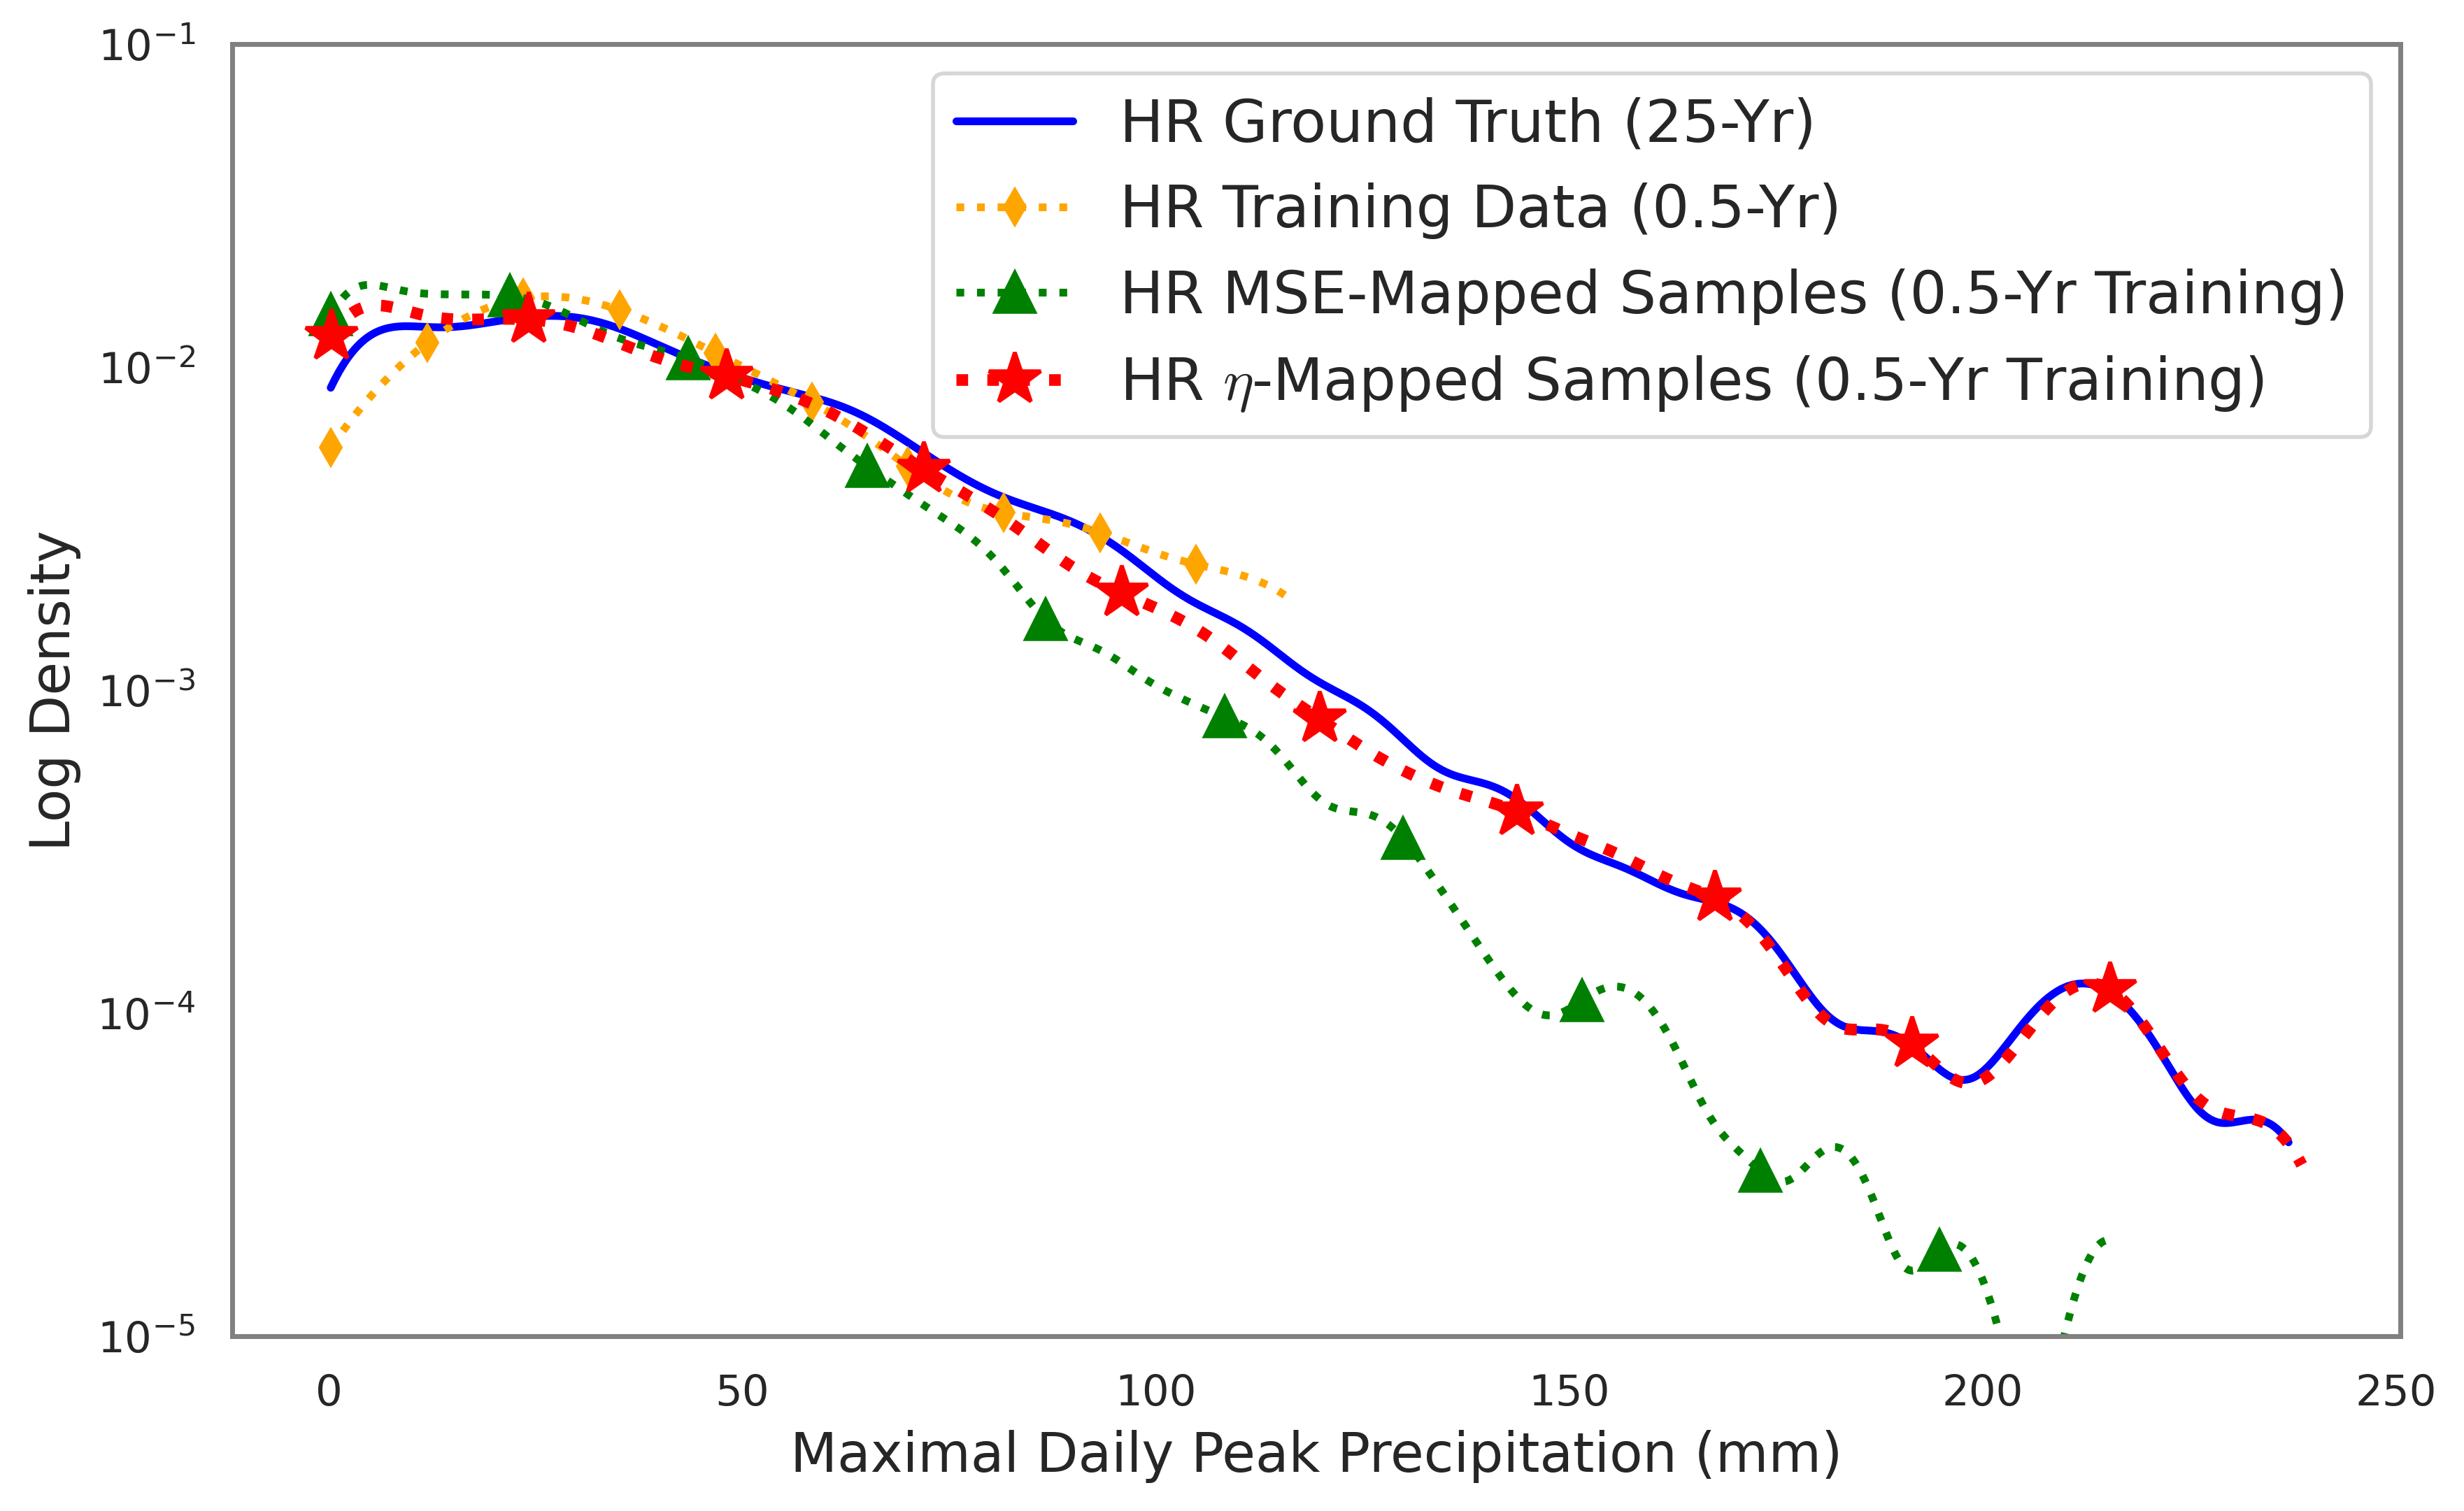

In [26]:
# full PDF comparison
max_values_eta = np.max(full_output_eta, axis=(1,2))
# max_values_eta = max_values_eta[max_values_eta < sorted_max_values[-1]]
# tail_values_eta = max_values_eta[max_values_eta > w1_tail_thresh]

y_eval_true, py_true, _ = get_data_pdf(data=torch.tensor(max_values), data_all=torch.tensor(max_values))
y_eval_mse, py_mse, _ = get_data_pdf(data=torch.tensor(max_values_mse), data_all=torch.tensor(max_values_mse))
y_eval_eta, py_eta, _ = get_data_pdf(data=torch.tensor(max_values_eta), data_all=torch.tensor(max_values_eta))

# Plotting the two KDEs for comparison
plt.figure(figsize=(10, 6), dpi=400)

# Plot the PDFs
plt.plot(y_eval_true, py_true, label=r"HR Ground Truth (25-Yr)", color='blue', linestyle='-', linewidth=2)
plt.plot(y_eval_tp_train, py_tp_train, label=r"HR Training Data (0.5-Yr)", color='orange', linestyle=':', 
         marker='d', markevery=100, linewidth=2)
plt.plot(y_eval_mse, py_mse, label=r"HR MSE-Mapped Samples (0.5-Yr Training)", color='green', linestyle=':', 
         marker='^', markevery=100, linewidth=2, markersize=10)
plt.plot(y_eval_eta, py_eta, label=r"HR $\eta$-Mapped Samples (0.5-Yr Training)", color='red', linestyle=':', 
         marker='*', markersize=14, markevery=100, linewidth=3)
# plt.hist(max_values, bins=40, density=True, alpha=0.3, color="gray", label=r"$\{y(x_i)\}$")

# plot the KDE truncated tails
# plt.plot(y_eval_true[y_eval_true > 150], py_true[y_eval_true > 150], label="25 Years True")
# plt.plot(y_eval_mse[y_eval_mse > 150], py_mse[y_eval_mse > 150], label="25 Years MSE", linestyle='-.')
# plt.plot(y_eval_eta[y_eval_eta > 150], py_eta[y_eval_eta > 150], label=fr"25 Years $\eta$", linestyle='--')

# Plot the tails
# plt.plot(y_tail_eval_true, py_tail_true, label="25 Years True Tail")
# plt.plot(y_tail_eval_mse, py_tail_mse, label="25 Years MSE Tail", linestyle='-.')
# plt.plot(y_tail_eval_eta, py_tail_eta, label=fr"25 Years $\eta$ Tail", linestyle='--')

# Add plot labels and title
plt.xlabel("Maximal Daily Peak Precipitation (mm)", fontsize=14)
plt.ylabel("Log Density", fontsize=14)
# plt.title("PDF of Regional Max Precipitation", fontsize=14)
plt.ylim(1e-5,1e-1)
plt.yscale('log')
plt.legend(prop={'size': 15})

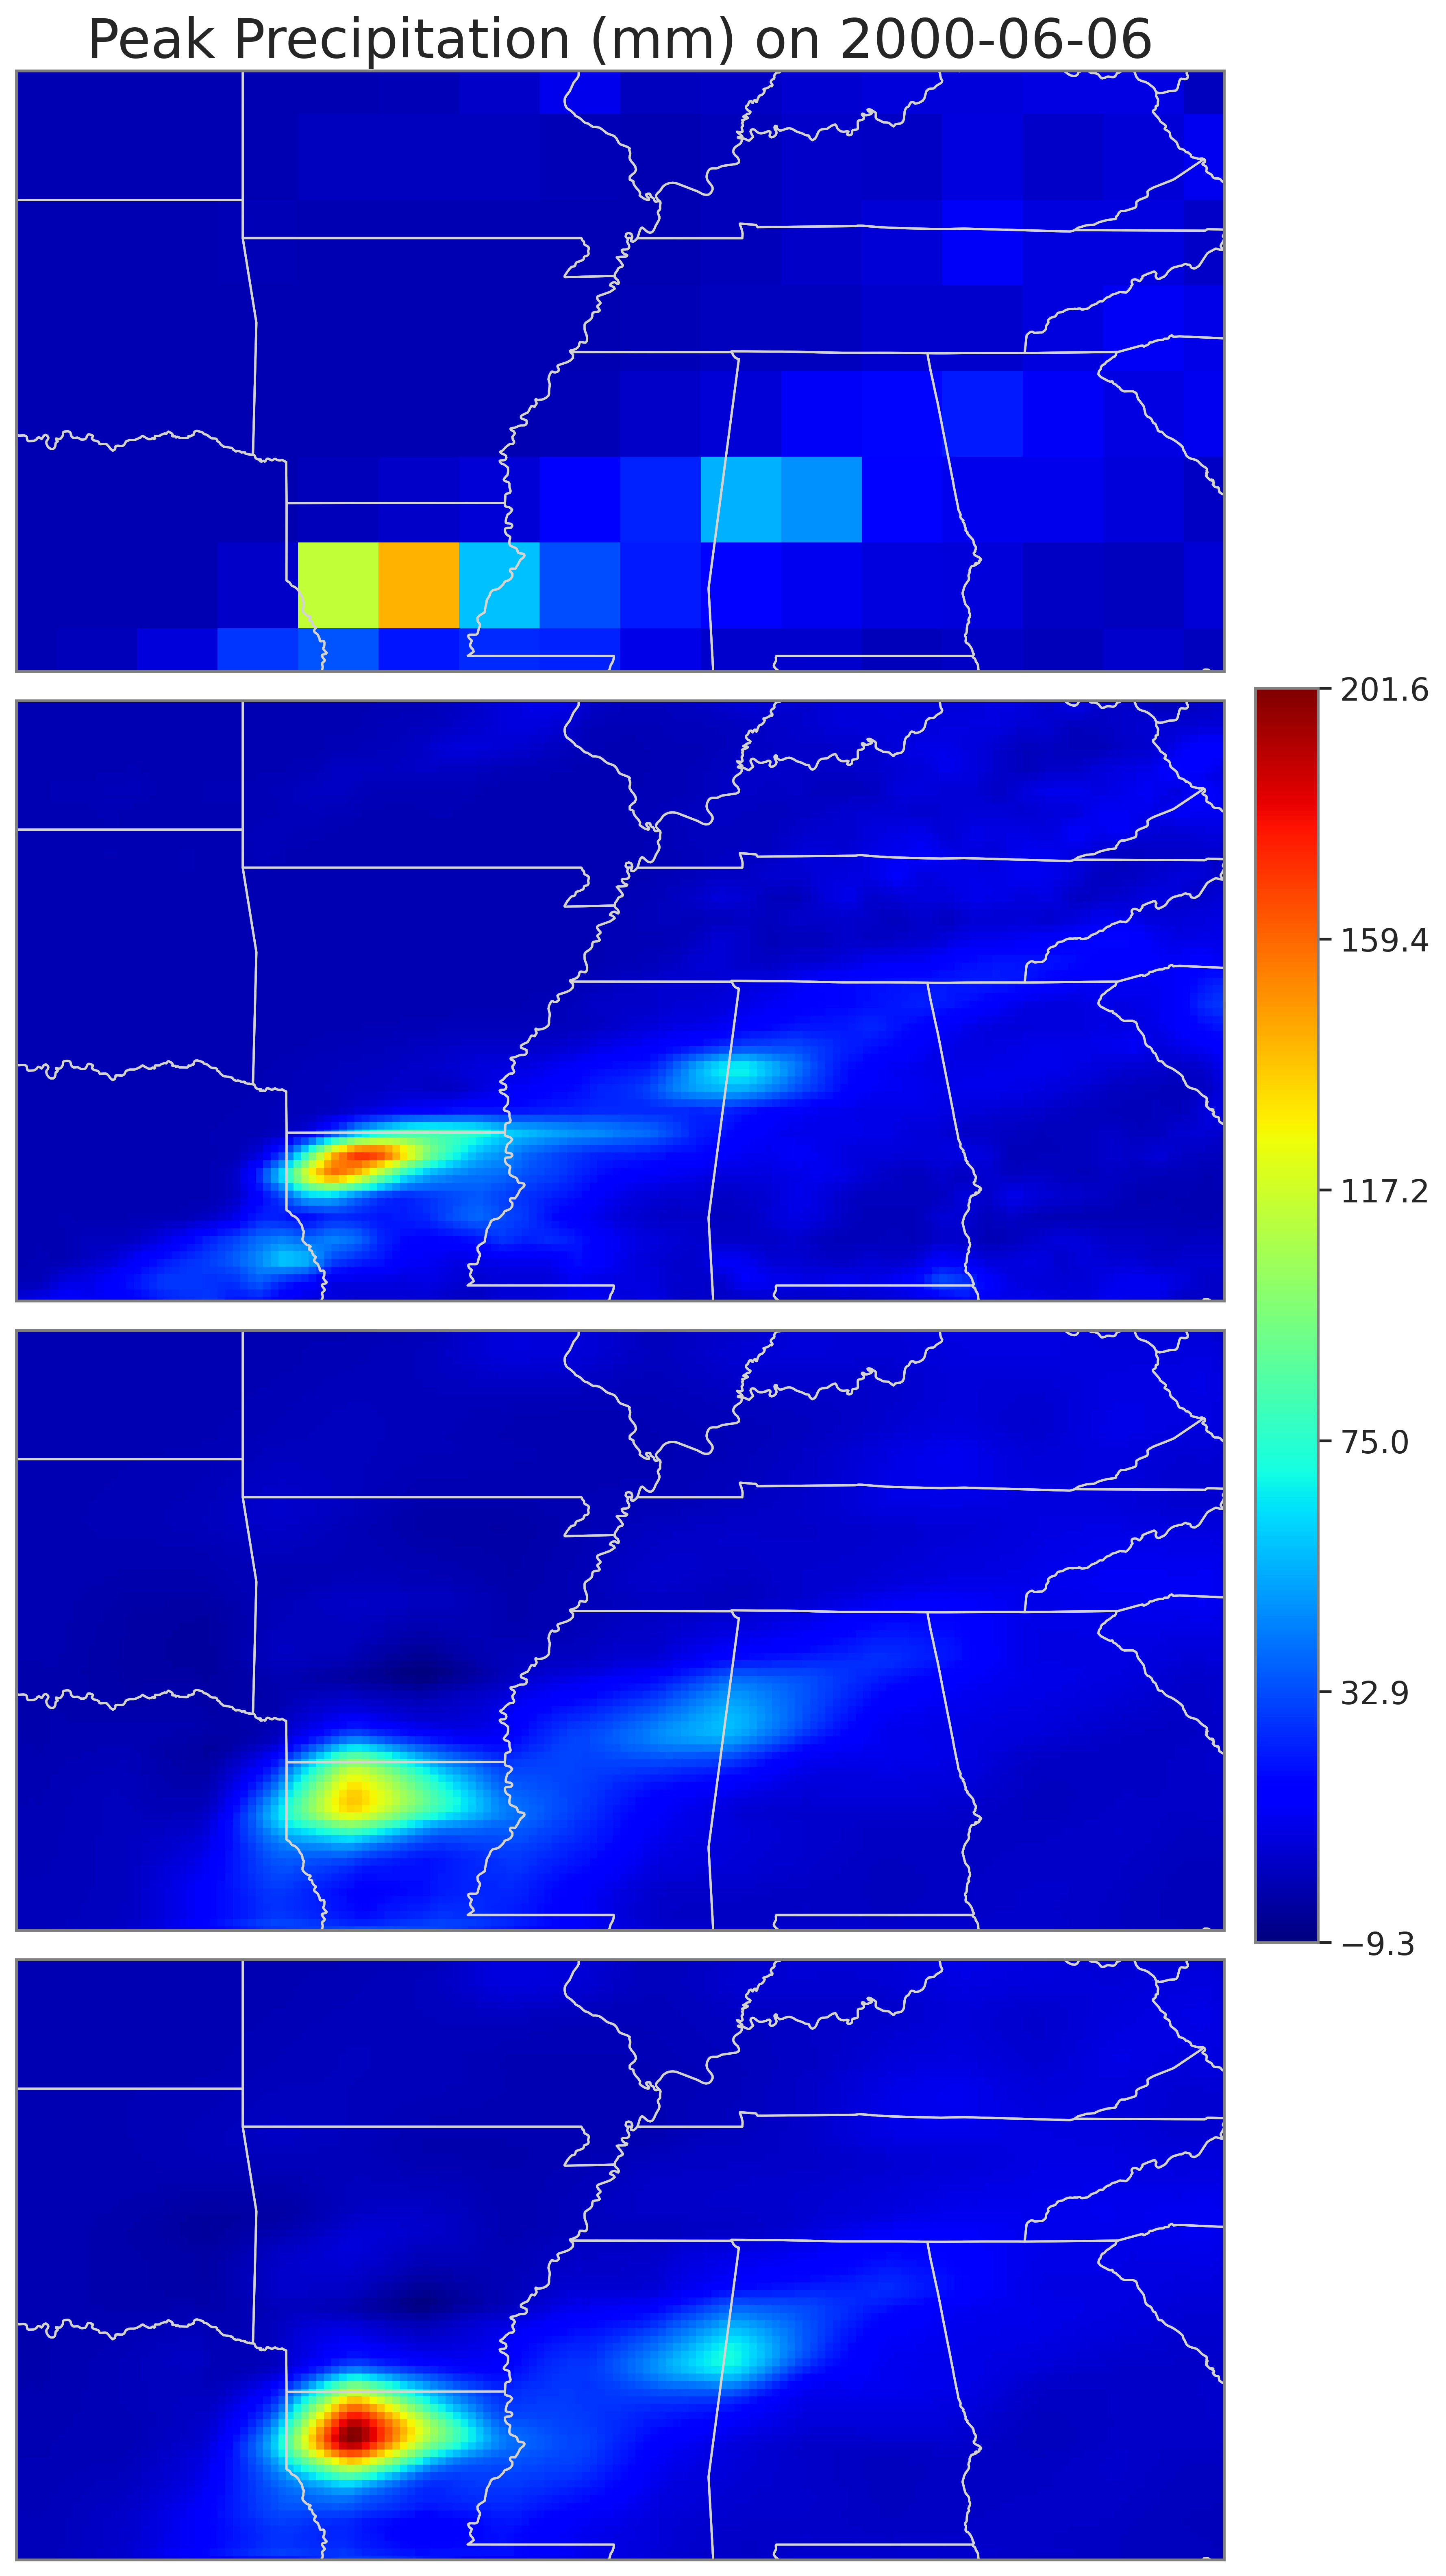

In [ ]:
visualize_day = 522
time_str = str(tp.time.values[visualize_day])[:10]
ds_field = tp_trim_ds_numpy[visualize_day]
true_field = tp_trim_numpy[visualize_day]
mse_field = full_output_mse[visualize_day]
eta_field = full_output_eta[visualize_day]
fig, axes = plot_nfields(ds_field, true_field, mse_field, eta_field, title_date=time_str, cmap="jet", longitudes=tp.longitude.values, latitudes=tp.latitude.values, add_ylabel=False)



# Coverage Statistics

(41,)
(6,)
(41,)
(31,)
(3,)
(30,)
(22,)
(2,)
(24,)


AxisError: axis 1 is out of bounds for array of dimension 1

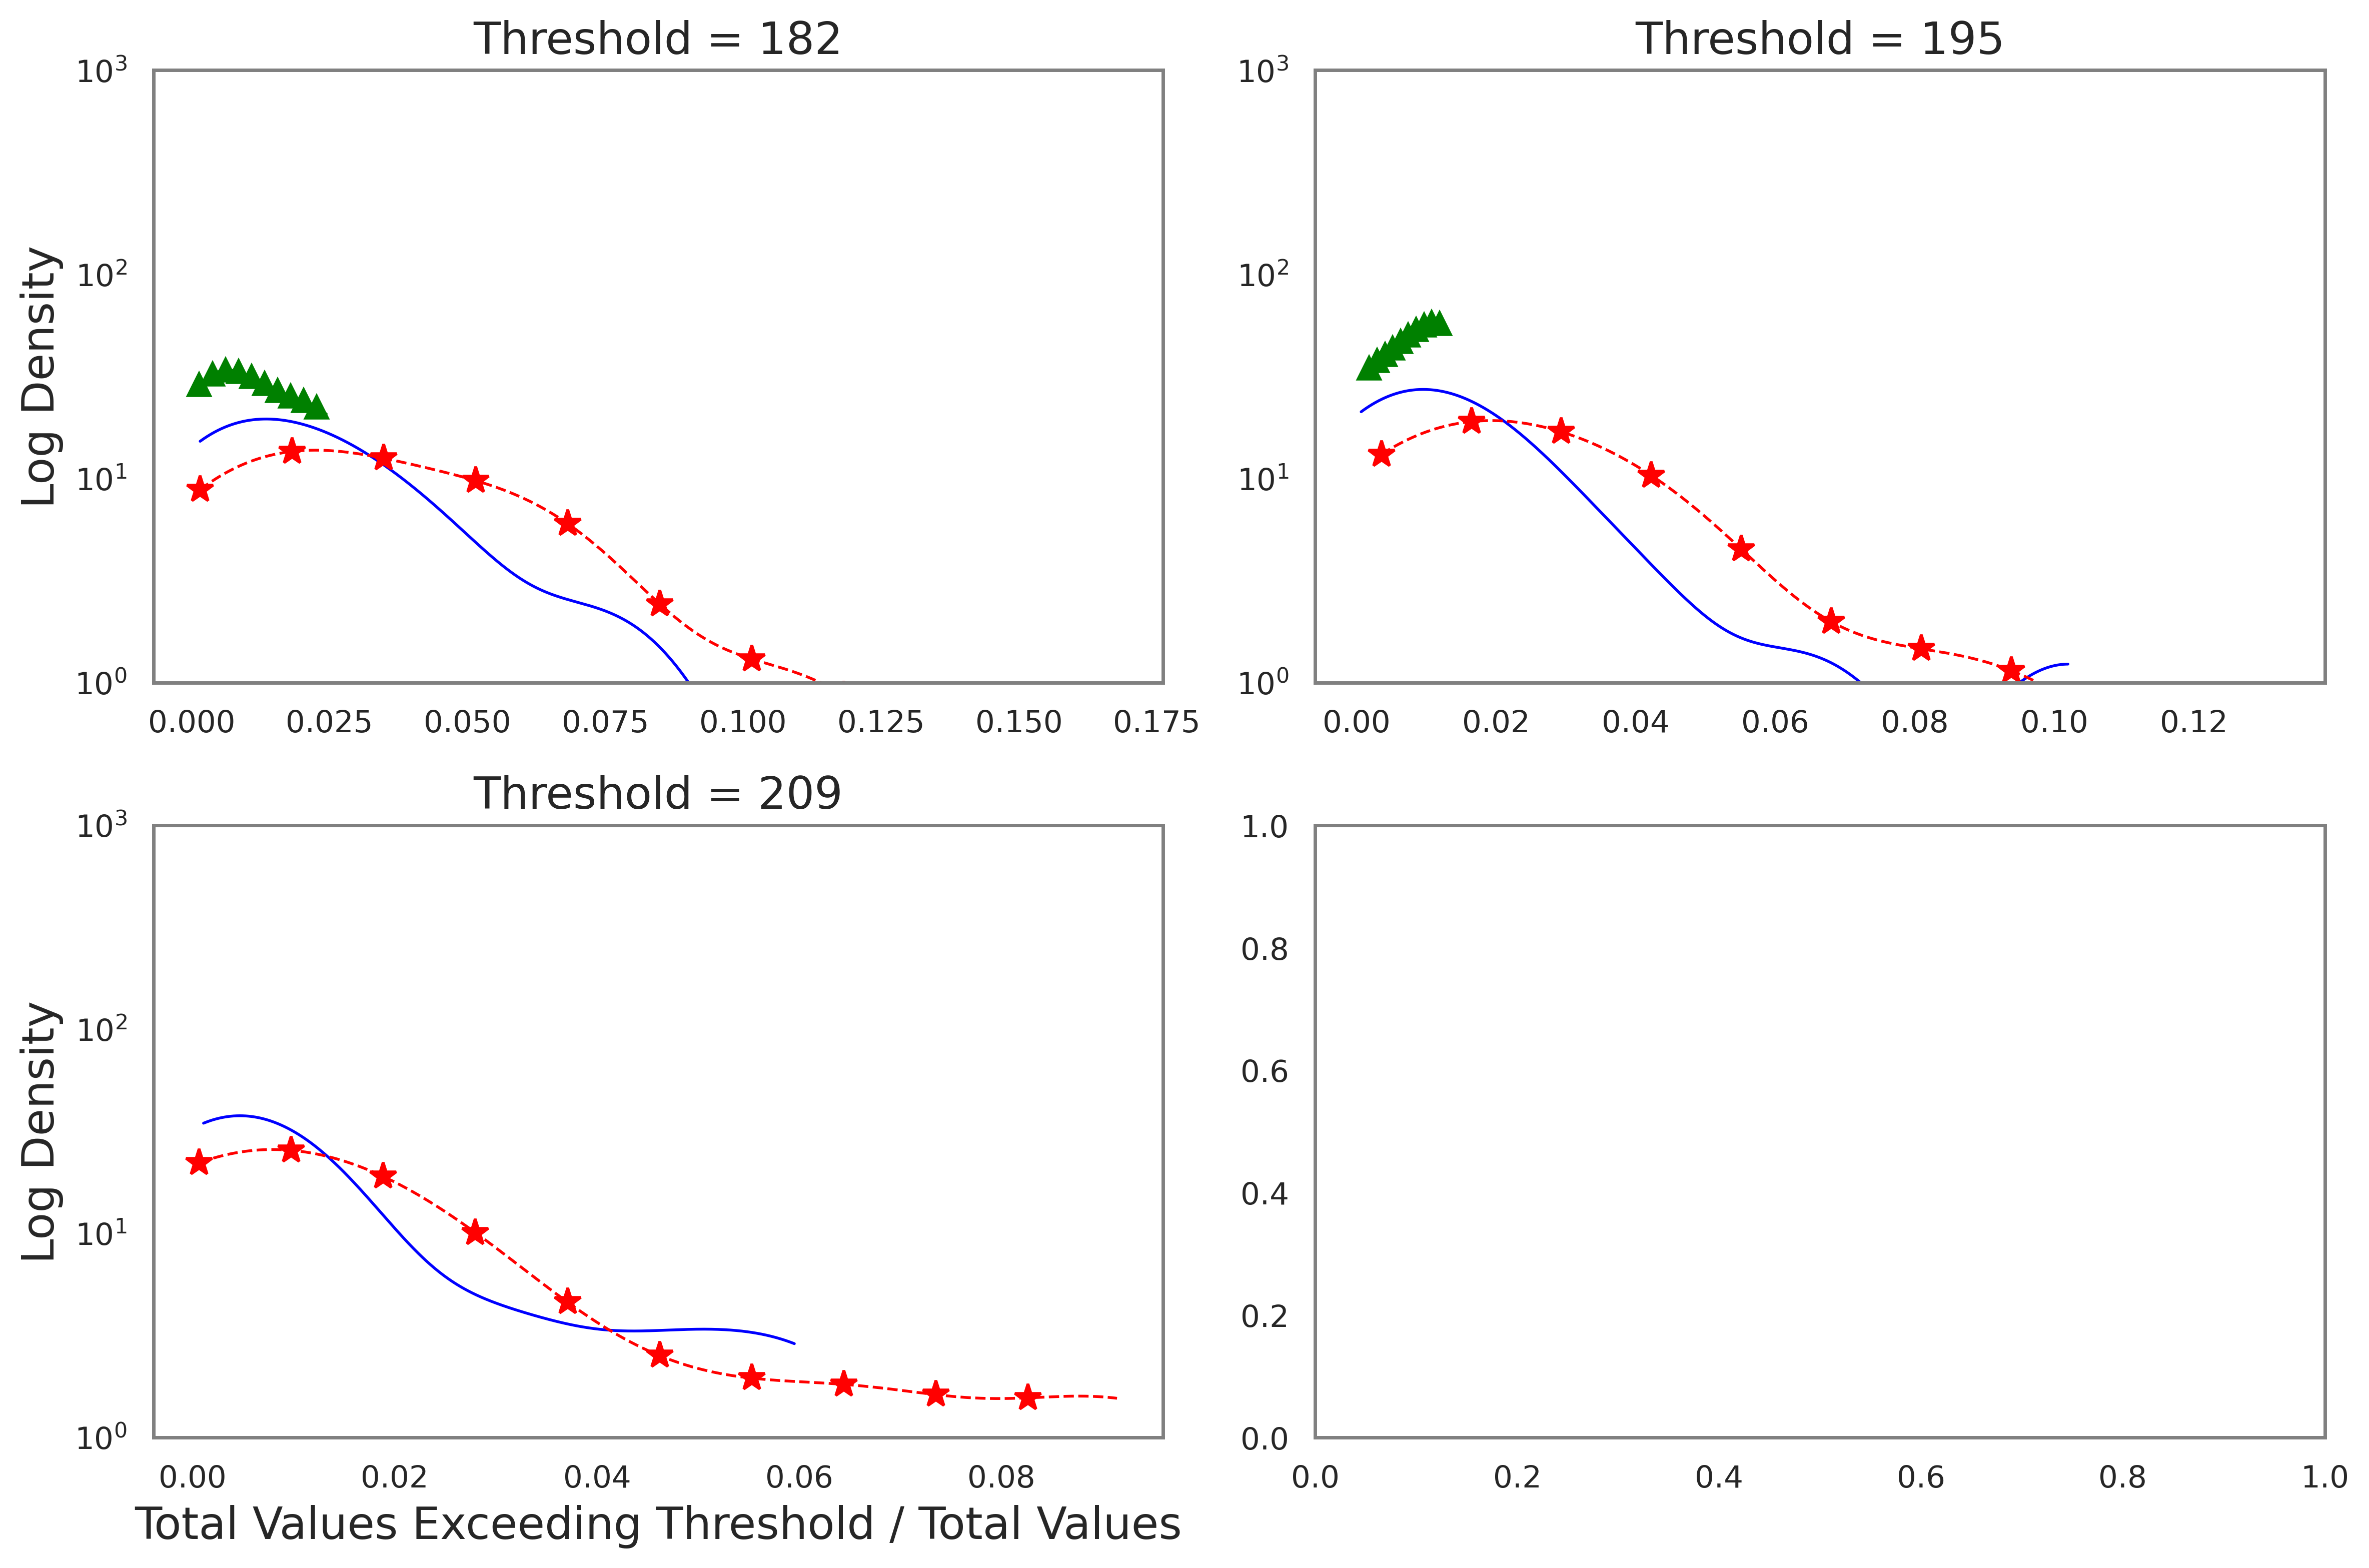

In [35]:
def get_coverage_stats(output : np.ndarray, threshold : float):

    # sum the values in each snapshot of output (N,H,W) that are greater than the threshold
    # divide by the total sum of value in each snapshot to normalize
    output_total_sum = np.sum(output, axis=(1,2))
    N, H, W = output.shape
    # only keep the values in output that are greater than the threshold but 
    thresholded_output = output * (output >= threshold)
    thresholded_output_sum = np.sum(thresholded_output, axis=(1,2))
    coverage_stats = thresholded_output_sum / output_total_sum
    return coverage_stats

max_values = np.max(tp_trim_numpy, axis=(1,2))
max_values_mse = np.max(full_output_mse, axis=(1,2))
max_values_eta = np.max(full_output_eta, axis=(1,2))
thresholds = np.linspace(174+8,214+8,4)
fig, ax = plt.subplots(2,2,figsize=(12, 8), dpi=400)
for i, threshold in enumerate(thresholds):
    # preprocess the data
    # only keep the snapshots with max value greater than threshold
    tp_trim_numpy_tail = tp_trim_numpy[max_values >= threshold]
    full_output_mse_tail = full_output_mse[max_values_mse >= threshold]
    full_output_eta_tail = full_output_eta[max_values_eta >= threshold]

    if not full_output_mse_tail.any():
        full_output_mse_tail = np.array([1e-10])

    coverage_true = get_coverage_stats(tp_trim_numpy_tail, threshold)
    coverage_mse = get_coverage_stats(full_output_mse_tail, threshold)
    coverage_eta = get_coverage_stats(full_output_eta_tail, threshold)

    coverage_true = coverage_true + 1e-10
    coverage_mse = coverage_mse + 1e-10
    coverage_eta = coverage_eta + 1e-10
    print(coverage_true.shape)
    print(coverage_mse.shape)
    print(coverage_eta.shape)

    # compute the pdf of the coverage stats
    c_true, pc_true, _ = get_data_pdf(data=torch.tensor(coverage_true), data_all=torch.tensor(coverage_true))
    c_mse, pc_mse, _ = get_data_pdf(data=torch.tensor(coverage_mse), data_all=torch.tensor(coverage_mse))
    c_eta, pc_eta, _ = get_data_pdf(data=torch.tensor(coverage_eta), data_all=torch.tensor(coverage_eta))

    I = i // 2
    J = i % 2
    if I == 1 and J == 1:
        ax[I,J].plot(c_true, pc_true, label="HR Ground Truth (25-Yr)", color='blue', linestyle='-', linewidth=1)
        ax[I,J].plot(c_mse, pc_mse, label="HR MSE-Mapped Samples (0.5-Yr Training)", color='green', marker='^', 
             markevery=100, markersize=8, linestyle=':', linewidth=1)
        ax[I,J].plot(c_eta, pc_eta, label="HR $\eta$-Mapped Samples (0.5-Yr Training)", color='red', marker='*', 
             markevery=100, markersize=10, linestyle='--', linewidth=1)
        ax[I,J].legend(prop={'size': 12})
    else:
        ax[I,J].plot(c_true, pc_true, color='blue', linestyle='-', linewidth=1)
        ax[I,J].plot(c_mse, pc_mse, color='green', marker='^', markevery=100, markersize=8, linestyle=':', linewidth=1)
        ax[I,J].plot(c_eta, pc_eta, color='red', marker='*', markevery=100, markersize=10, linestyle='--', linewidth=1)

    ax[I,J].set_yscale('log')
    ax[I,J].set_ylim(1,1e3)
    if I == 1:
        ax[I,J].set_xlabel("Total Values Exceeding Threshold / Total Values", fontsize=16)
    if J == 0:
        ax[I,J].set_ylabel("Log Density", fontsize=16)
    ax[I,J].set_title(f"Threshold = {threshold:.0f}", fontsize=16)
    plt.tight_layout()
    # assert False